# Monte Carlo Simulation of Neutron Transport Through Heterogeneous Water-Carbon Slab
- Author: Joel Minj
- Semester 1 Project
## Overview
A Monte Carlo simulation of neutrons traveling through a **heterogeneous slab** consisting of:
- **Region 1 (0-10 cm):** Water (H₂O) - effective moderator/shield
- **Region 2 (10-30 cm):** Graphite (Carbon-12) - transparent to neutrons

**Description:**
- Multi-region transport with surface crossing logic
- Correct Center-of-Mass to Lab frame kinematics for H, O, and C scattering
- Material-dependent cross-sections (ENDF-based)
- Implicit capture variance reduction + Russian Roulette
- Batch statistics for uncertainty quantification
- Track visualization showing material-dependent path characteristics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Nuclear Physics Constants - Heterogeneous Materials

In [2]:
class NuclearConstants:
    """Fundamental constants in nuclear physics for multiple materials"""
    AVOGADRO = 6.02214076e23
    
    # ========== MATERIAL 1: WATER (H₂O) ==========
    WATER_DENSITY = 1.0  # g/cm³
    WATER_MOL_MASS = 18.01528  # g/mol
    
    N_WATER_MOL = WATER_DENSITY / WATER_MOL_MASS  # mol/cm³
    N_H_WATER = N_WATER_MOL * AVOGADRO * 2   # 2 H atoms per H₂O
    N_O_WATER = N_WATER_MOL * AVOGADRO       # 1 O atom per H₂O
    
    # ========== MATERIAL 2: GRAPHITE (CARBON-12) ==========
    CARBON_DENSITY = 1.70  # g/cm³ (reactor-grade graphite)
    CARBON_MOL_MASS = 12.011  # g/mol
    
    N_C_GRAPHITE = (CARBON_DENSITY / CARBON_MOL_MASS) * AVOGADRO  # C atoms/cm³
    
    @staticmethod
    def print_summary():
        print(f"{'='*70}")
        print(f"MATERIAL PROPERTIES")
        print(f"{'='*70}")
        print(f"\nWater (H₂O):")
        print(f"  Density: {NuclearConstants.WATER_DENSITY} g/cm³")
        print(f"  N_H: {NuclearConstants.N_H_WATER:.3e} atoms/cm³")
        print(f"  N_O: {NuclearConstants.N_O_WATER:.3e} atoms/cm³")
        print(f"\nGraphite (C-12):")
        print(f"  Density: {NuclearConstants.CARBON_DENSITY} g/cm³")
        print(f"  N_C: {NuclearConstants.N_C_GRAPHITE:.3e} atoms/cm³")
        print(f"{'='*70}\n")

NuclearConstants.print_summary()

MATERIAL PROPERTIES

Water (H₂O):
  Density: 1.0 g/cm³
  N_H: 6.686e+22 atoms/cm³
  N_O: 3.343e+22 atoms/cm³

Graphite (C-12):
  Density: 1.7 g/cm³
  N_C: 8.524e+22 atoms/cm³



## Section 2: Multi-Material Cross-Section Models

In [3]:
class CrossSectionModels:
    """
    Energy-dependent ENDF-based cross-sections (in barns) for H, O, and C.
    Materials: Water and Graphite (Carbon-12).
    """
    
    # ========== HYDROGEN (H-1) ==========
    @staticmethod
    def sigma_elastic_hydrogen(E_MeV):
        """Elastic scattering cross-section for hydrogen (H-1)"""
        E = np.atleast_1d(E_MeV)
        sigma = np.zeros_like(E, dtype=float)
        
        # Thermal/Epithermal (E < 0.001 MeV)
        mask1 = E < 0.001
        sigma[mask1] = 20.4
        
        # Fast neutron region (E >= 0.001 MeV)
        # ENDF-based fit: σ(E) ≈ 4.5/√E + 0.5
        mask2 = E >= 0.001
        E_fast = E[mask2]
        sigma[mask2] = 4.5 / np.sqrt(E_fast) + 0.5
        
        return sigma[0] if len(sigma) == 1 else sigma
    
    @staticmethod
    def sigma_absorption_hydrogen(E_MeV):
        """Absorption (capture) cross-section for hydrogen: negligible above thermal"""
        return 0.33e-3 / np.sqrt(np.maximum(E_MeV, 1e-9) / 2.53e-8)
    
    # ========== OXYGEN (O-16) ==========
    @staticmethod
    def sigma_elastic_oxygen(E_MeV):
        """Elastic scattering cross-section for oxygen (O-16)"""
        return 3.8 + 0.5 * np.exp(-E_MeV)
    
    @staticmethod
    def sigma_absorption_oxygen(E_MeV):
        """Absorption cross-section for oxygen: very small"""
        return 0.2e-3 / np.sqrt(np.maximum(E_MeV, 1e-9) / 2.53e-8)
    
    # ========== CARBON-12 (GRAPHITE) ==========
    @staticmethod
    def sigma_elastic_carbon(E_MeV):
        """Elastic scattering cross-section for carbon-12"""
        # Carbon is relatively transparent: ~4.75 barns, stable across energy range
        # Slight drop-off at very high energies (> 2 MeV)
        E = np.atleast_1d(E_MeV)
        sigma = np.where(E > 2.0, 
                        4.75 * np.exp(-0.1 * (E - 2.0)),
                        4.75 * np.ones_like(E))
        return sigma[0] if len(sigma) == 1 else sigma
    
    @staticmethod
    def sigma_absorption_carbon(E_MeV):
        """Absorption cross-section for carbon: extremely small"""
        # Graphite is very pure with minimal capture
        return 0.0035e-3 / np.sqrt(np.maximum(E_MeV, 1e-9) / 2.53e-8)
    
    @staticmethod
    def get_cross_sections(x_pos, E_MeV, interface_x=10.0):
        """
        Returns macroscopic cross sections (cm⁻¹) and material type.
        
        Args:
            x_pos: Position in slab (cm)
            E_MeV: Neutron energy (MeV)
            interface_x: Location of water-carbon interface (default 10 cm)
        
        Returns:
            (Sig_s, Sig_a, Sig_t, material_name)
        """
        if x_pos < interface_x:
            # ===== WATER REGION =====
            sig_h_el = CrossSectionModels.sigma_elastic_hydrogen(E_MeV)
            sig_o_el = CrossSectionModels.sigma_elastic_oxygen(E_MeV)
            sig_h_ab = CrossSectionModels.sigma_absorption_hydrogen(E_MeV)
            sig_o_ab = CrossSectionModels.sigma_absorption_oxygen(E_MeV)
            
            # Macroscopic cross-sections (convert barns to cm⁻¹)
            Sig_s = (sig_h_el * NuclearConstants.N_H_WATER + 
                     sig_o_el * NuclearConstants.N_O_WATER) * 1e-24
            Sig_a = (sig_h_ab * NuclearConstants.N_H_WATER + 
                     sig_o_ab * NuclearConstants.N_O_WATER) * 1e-24
            
            return Sig_s, Sig_a, Sig_s + Sig_a, 'water'
        
        else:
            # ===== CARBON (GRAPHITE) REGION =====
            sig_c_el = CrossSectionModels.sigma_elastic_carbon(E_MeV)
            sig_c_ab = CrossSectionModels.sigma_absorption_carbon(E_MeV)
            
            # Macroscopic cross-sections
            Sig_s = sig_c_el * NuclearConstants.N_C_GRAPHITE * 1e-24
            Sig_a = sig_c_ab * NuclearConstants.N_C_GRAPHITE * 1e-24
            
            return Sig_s, Sig_a, Sig_s + Sig_a, 'carbon'

print("Multi-material cross-section models initialized!")

Multi-material cross-section models initialized!


## Section 3: Geometry and Neutron Classes

In [4]:
@dataclass
class HeterogeneousGeometry:
    """Defines a heterogeneous slab with water and carbon regions"""
    water_thick: float = 10.0      # Water thickness (0 to 10 cm)
    carbon_thick: float = 20.0     # Carbon thickness (10 to 30 cm)
    slab_width: float = 20.0       # Y-direction (±10 cm)
    slab_height: float = 30.0      # Z-direction (±15 cm)
    
    @property
    def interface_x(self):
        """Location of water-carbon interface"""
        return self.water_thick
    
    @property
    def max_x(self):
        """Downstream boundary"""
        return self.water_thick + self.carbon_thick
    
    def get_material(self, x):
        """Return material name at position x"""
        if x < self.interface_x:
            return 'water'
        else:
            return 'carbon'
    
    def distance_to_boundary(self, x, u):
        """Distance to upstream/downstream boundary"""
        if u > 0:
            return (self.max_x - x) / u if u > 1e-9 else float('inf')
        elif u < 0:
            return (0.0 - x) / u if u < -1e-9 else float('inf')
        else:
            return float('inf')
    
    def distance_to_interface(self, x, u):
        """Distance to water-carbon interface"""
        if abs(u) < 1e-9:
            return float('inf')
        
        if x < self.interface_x and u > 0:
            return (self.interface_x - x) / u
        elif x > self.interface_x and u < 0:
            return (self.interface_x - x) / u
        else:
            return float('inf')


class HeterogeneousNeutron:
    """
    Neutron particle for heterogeneous transport.
    Tracks position, energy, direction, and weight across material boundaries.
    """
    
    def __init__(self, energy=2.0):
        self.x, self.y, self.z = 0.0, 0.0, 0.0  # Source at origin
        self.E = energy
        self.weight = 1.0
        self.alive = True
        self.material = 'water'
        self.history = [(self.x, self.y, self.z)]
        
        # Isotropic direction
        phi = 2 * np.pi * np.random.random()
        mu = 2 * np.random.random() - 1
        theta = np.arccos(mu)
        self.u = np.sin(theta) * np.cos(phi)
        self.v = np.sin(theta) * np.sin(phi)
        self.w = np.cos(theta)
    
    def move(self, dist):
        """Move neutron by distance in current direction"""
        self.x += self.u * dist
        self.y += self.v * dist
        self.z += self.w * dist
        self.history.append((self.x, self.y, self.z))
    
    def scatter(self, A):
        """
        Elastic scattering with correct CM->Lab kinematics.
        
        Args:
            A: Mass number (1 for H, 16 for O, 12 for C)
        """
        alpha = ((A - 1) / (A + 1))**2
        mu_cm = 2 * np.random.random() - 1  # Isotropic in CM
        
        # Energy reduction
        E_new = self.E * ((1 + alpha) + (1 - alpha) * mu_cm) / 2.0
        
        # Lab scattering angle cosine
        mu_lab = (1 + A * mu_cm) / np.sqrt(1 + A**2 + 2 * A * mu_cm)
        
        # Rotation
        self.rotate_direction(mu_lab)
        self.E = E_new
    
    def rotate_direction(self, mu_lab):
        """Rotates direction vector by polar angle arccos(mu_lab)"""
        phi = 2 * np.pi * np.random.random()
        sin_t = np.sqrt(max(0, 1 - mu_lab**2))
        
        u, v, w = self.u, self.v, self.w
        if 1 - abs(w) < 1e-5:
            # Moving nearly parallel to z-axis
            self.u = sin_t * np.cos(phi)
            self.v = sin_t * np.sin(phi)
            self.w = mu_lab * np.sign(w) if w != 0 else mu_lab
        else:
            # General case: use rotation matrix
            fact = np.sqrt(1 - w**2)
            self.u = u * mu_lab + (u * w * sin_t * np.cos(phi) - v * sin_t * np.sin(phi)) / fact
            self.v = v * mu_lab + (v * w * sin_t * np.cos(phi) + u * sin_t * np.sin(phi)) / fact
            self.w = w * mu_lab - fact * sin_t * np.cos(phi)
        
        # Normalize to avoid drift
        norm = np.sqrt(self.u**2 + self.v**2 + self.w**2)
        if norm > 0:
            self.u, self.v, self.w = self.u/norm, self.v/norm, self.w/norm

print("Heterogeneous geometry and neutron classes initialized!")

Heterogeneous geometry and neutron classes initialized!


## Section 4: Heterogeneous Monte Carlo Transport Engine

In [5]:
class HeterogeneousMCSimulation:
    """
    Monte Carlo simulation for heterogeneous (multi-region) neutron transport.
    
    Features:
    - Multi-region transport with material-dependent cross-sections
    - Surface crossing logic (water-carbon interface at x=10 cm)
    - Implicit Capture + Russian Roulette variance reduction
    - Batch statistics for uncertainty quantification
    """
    
    def __init__(self, n_particles, geometry, n_batches=5):
        self.N = n_particles
        self.geo = geometry
        self.n_batches = n_batches
        self.batch_size = n_particles // n_batches
        
        # Tally Grids
        self.x_bins = np.linspace(0, self.geo.max_x, 61)  # 0.5 cm bins
        self.e_bins = np.logspace(-3, np.log10(2.5), 100)  # 1 keV to 2.5 MeV
        
        # Batch results storage
        self.batch_flux_results = []
        self.batch_spectrum_results = []
        self.batch_material_results = []  # Track neutrons per material
        
        # Final tallies (mean across batches)
        self.flux_x = np.zeros(len(self.x_bins) - 1)
        self.flux_x_std = np.zeros(len(self.x_bins) - 1)
        self.spectrum = np.zeros(len(self.e_bins) - 1)
        self.spectrum_std = np.zeros(len(self.e_bins) - 1)
        
        # Material-specific tallies
        self.flux_water = np.zeros(len(self.x_bins) - 1)
        self.flux_carbon = np.zeros(len(self.x_bins) - 1)
        
        # For plotting tracks
        self.tracks = []
        
        # Statistics
        self.total_weight_killed = 0
        self.particles_killed = 0
    
    def run(self):
        """Run the heterogeneous Monte Carlo simulation with batching"""
        print(f"Running heterogeneous simulation with {self.N} neutrons in {self.n_batches} batches...")
        print(f"Geometry: Water (0-{self.geo.interface_x} cm) | Carbon ({self.geo.interface_x}-{self.geo.max_x} cm)")
        print(f"Batch size: {self.batch_size} neutrons/batch\n")
        
        start_time = time.time()
        
        for batch in range(self.n_batches):
            print(f"Batch {batch+1}/{self.n_batches}...", end=" ")
            batch_start = time.time()
            
            # Initialize batch tallies
            batch_flux = np.zeros(len(self.x_bins) - 1)
            batch_spectrum = np.zeros(len(self.e_bins) - 1)
            batch_material = np.zeros(len(self.x_bins) - 1)
            
            for i in range(self.batch_size):
                n = HeterogeneousNeutron(energy=INITIAL_ENERGY)
                
                # Store first 100 tracks for visualization
                record_track = (batch == 0 and i < 100)
                
                while n.alive:
                    # Get cross-sections at current position
                    Sig_s, Sig_a, Sig_t, material = CrossSectionModels.get_cross_sections(n.x, n.E)
                    n.material = material
                    
                    # Ensure no division by zero
                    if Sig_t <= 1e-10:
                        n.alive = False
                        continue
                    
                    # Sample distance to collision
                    d_coll = -np.log(np.random.random()) / Sig_t
                    
                    # Calculate distances to boundaries
                    d_bound = self.geo.distance_to_boundary(n.x, n.u)
                    d_interface = self.geo.distance_to_interface(n.x, n.u)
                    
                    # Determine which event occurs first
                    d_step = min(d_coll, d_bound, d_interface)
                    
                    # Tally: Track Length Flux
                    self.tally_flux_x(n, d_step, batch_flux, batch_material)
                    
                    # Move particle
                    n.move(d_step)
                    
                    if d_step == d_bound:
                        # ===== LEAKAGE =====
                        n.alive = False
                    
                    elif d_step == d_interface:
                        # ===== SURFACE CROSSING (Material change) =====
                        # Nudge slightly into new material to avoid logic loops
                        n.x += n.u * 1e-6
                        n.material = self.geo.get_material(n.x)
                        # Continue without collision (energy/direction unchanged)
                        continue
                    
                    else:
                        # ===== COLLISION =====
                        # Implicit Capture: reduce weight by survival probability
                        survive_prob = Sig_s / (Sig_t + 1e-20)
                        n.weight *= survive_prob
                        
                        # Russian Roulette for low-weight particles
                        weight_cutoff = 1e-4
                        if n.weight < weight_cutoff:
                            prob_survive = 0.1
                            if np.random.random() < prob_survive:
                                n.weight /= prob_survive
                            else:
                                self.total_weight_killed += n.weight
                                self.particles_killed += 1
                                n.alive = False
                                continue
                        
                        # Energy cutoff
                        if n.E < 1e-5:
                            n.alive = False
                            continue
                        
                        # Determine which nucleus we scattered from
                        old_E = n.E
                        
                        if n.material == 'water':
                            # Decide between H and O (probability ratio of cross-sections)
                            sig_h_el = CrossSectionModels.sigma_elastic_hydrogen(n.E)
                            sig_o_el = CrossSectionModels.sigma_elastic_oxygen(n.E)
                            if np.random.random() < (sig_h_el * NuclearConstants.N_H_WATER) / \
                                                     (sig_h_el * NuclearConstants.N_H_WATER + sig_o_el * NuclearConstants.N_O_WATER):
                                n.scatter(A=1.0)  # Hydrogen
                            else:
                                n.scatter(A=16.0)  # Oxygen
                        
                        else:
                            # Carbon-12
                            n.scatter(A=12.0)
                        
                        # Tally energy spectrum
                        idx = np.searchsorted(self.e_bins, n.E) - 1
                        if 0 <= idx < len(batch_spectrum):
                            batch_spectrum[idx] += n.weight
                
                if record_track:
                    self.tracks.append(np.array(n.history))
            
            # Store batch results
            self.batch_flux_results.append(batch_flux)
            self.batch_spectrum_results.append(batch_spectrum)
            self.batch_material_results.append(batch_material)
            
            batch_elapsed = time.time() - batch_start
            print(f"completed in {batch_elapsed:.2f}s")
        
        self.compute_batch_statistics()
        
        elapsed = time.time() - start_time
        print(f"\nTotal simulation time: {elapsed:.2f}s\n")
    
    def compute_batch_statistics(self):
        """Compute mean and standard error from batch results"""
        flux_array = np.array(self.batch_flux_results)
        spectrum_array = np.array(self.batch_spectrum_results)
        
        # Normalize by batch size and bin volume
        vol_bin = ((self.x_bins[1] - self.x_bins[0]) * 
                   (self.geo.slab_width) * 
                   (self.geo.slab_height))
        
        flux_array_norm = flux_array / (self.batch_size * vol_bin)
        
        # Calculate mean and standard error
        self.flux_x = np.mean(flux_array_norm, axis=0)
        flux_std = np.std(flux_array_norm, axis=0, ddof=1)
        self.flux_x_std = flux_std / np.sqrt(self.n_batches)
        
        # Spectrum normalization
        spectrum_array_norm = spectrum_array / self.batch_size
        self.spectrum = np.mean(spectrum_array_norm, axis=0)
        spectrum_std = np.std(spectrum_array_norm, axis=0, ddof=1)
        self.spectrum_std = spectrum_std / np.sqrt(self.n_batches)
        
        print(f"{'='*70}")
        print(f"BATCH STATISTICS (n_batches={self.n_batches})")
        print(f"{'='*70}")
        print(f"Russian Roulette Statistics:")
        print(f"  Particles killed by roulette: {self.particles_killed}")
        print(f"  Total weight eliminated: {self.total_weight_killed:.4e}")
        print(f"  (These are unbiased reductions - fair game maintained)")
        print(f"{'='*70}\n")
    
    def tally_flux_x(self, neutron, dist, batch_array, material_array):
        """Track Length Estimator for Flux vs X"""
        # Handle particles moving parallel to YZ plane (u ~ 0)
        if abs(neutron.u) < 1e-9:
            idx = np.searchsorted(self.x_bins, neutron.x) - 1
            if 0 <= idx < len(batch_array):
                batch_array[idx] += neutron.weight * dist
            return
        
        step = 1 if neutron.u > 0 else -1
        x_current = neutron.x  # Start of step (tally happens before move)
        idx = np.searchsorted(self.x_bins, x_current) - 1
        rem_dist = dist
        
        while rem_dist > 0:
            # Check if particle is outside grid
            if not (0 <= idx < len(batch_array)):
                break
            
            # Calculate distance to the next bin edge
            if step > 0:
                # Moving Right: Distance to right edge (idx + 1)
                dist_to_edge = (self.x_bins[idx + 1] - x_current) / abs(neutron.u)
            else:
                # Moving Left: Distance to left edge (idx)
                # FIX: Swap order to keep distance positive (Current - Target)
                dist_to_edge = (x_current - self.x_bins[idx]) / abs(neutron.u)
            
            # Distance to tally in this bin is min(remaining flight, dist to edge)
            d_step = min(rem_dist, dist_to_edge + 1e-12)
            
            # Accumulate flux: weight * distance
            batch_array[idx] += neutron.weight * d_step
            
            # Update coordinate for next iteration
            x_current += neutron.u * d_step
            rem_dist -= d_step
            idx += step

print("Heterogeneous Monte Carlo simulation engine initialized!")

Heterogeneous Monte Carlo simulation engine initialized!


## Section 5: Simulation - Heterogeneous Configuration

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

N_NEUTRONS = 200000       # Total neutrons
N_BATCHES = 5             # Number of batches for error estimation
INITIAL_ENERGY = 2.0      # Initial energy (MeV) - fission-like spectrum

# ============================================================================
# DIAGNOSTIC: Cross-sections at source energy
# ============================================================================

print("="*70)
print("CROSS-SECTION DIAGNOSTIC (E = 2.0 MeV)")
print("="*70)

E_test = INITIAL_ENERGY

# Water region
sig_h = CrossSectionModels.sigma_elastic_hydrogen(E_test)
sig_o = CrossSectionModels.sigma_elastic_oxygen(E_test)
print(f"\nWATER REGION (0-10 cm):")
print(f"  H elastic: {sig_h:.3f} barns")
print(f"  O elastic: {sig_o:.3f} barns")

Sig_s_water, Sig_a_water, Sig_t_water, _ = CrossSectionModels.get_cross_sections(5.0, E_test)
mfp_water = 1.0 / Sig_t_water if Sig_t_water > 0 else float('inf')
print(f"  Σ_t (total): {Sig_t_water:.4f} cm⁻¹")
print(f"  MFP: {mfp_water:.4f} cm")

# Carbon region
sig_c = CrossSectionModels.sigma_elastic_carbon(E_test)
print(f"\nCARBON REGION (10-30 cm):")
print(f"  C elastic: {sig_c:.3f} barns")

Sig_s_carbon, Sig_a_carbon, Sig_t_carbon, _ = CrossSectionModels.get_cross_sections(20.0, E_test)
mfp_carbon = 1.0 / Sig_t_carbon if Sig_t_carbon > 0 else float('inf')
print(f"  Σ_t (total): {Sig_t_carbon:.4f} cm⁻¹")
print(f"  MFP: {mfp_carbon:.4f} cm")

mfp_ratio = mfp_carbon / mfp_water
print(f"\nMFP Ratio (Carbon/Water): {mfp_ratio:.2f}×")
print(f"✓ Carbon is {mfp_ratio:.1f}× more transparent than water")
print(f"{'='*70}\n")

# ============================================================================
# RUN HETEROGENEOUS SIMULATION
# ============================================================================

print("="*70)
print("HETEROGENEOUS NEUTRON TRANSPORT SIMULATION")
print("="*70)
print(f"\nConfiguration:")
print(f"  Water Region:       0-10 cm")
print(f"  Carbon Region:      10-30 cm")
print(f"  Total Neutrons:     {N_NEUTRONS:,}")
print(f"  Batches:            {N_BATCHES}")
print(f"  Batch Size:         {N_NEUTRONS // N_BATCHES:,}")
print(f"  Initial Energy:     {INITIAL_ENERGY} MeV")
print(f"  Variance Reduction: Implicit Capture + Russian Roulette")
print(f"  Cross-Sections:     ENDF-based")

# Define heterogeneous geometry
geo = HeterogeneousGeometry(water_thick=10.0, carbon_thick=20.0)

# Run simulation
sim = HeterogeneousMCSimulation(n_particles=N_NEUTRONS, geometry=geo, n_batches=N_BATCHES)
sim.run()

print(f"{'='*70}")

CROSS-SECTION DIAGNOSTIC (E = 2.0 MeV)

WATER REGION (0-10 cm):
  H elastic: 3.682 barns
  O elastic: 3.868 barns
  Σ_t (total): 0.3755 cm⁻¹
  MFP: 2.6635 cm (SHORT - effective shield)

CARBON REGION (10-30 cm):
  C elastic: 4.750 barns
  Σ_t (total): 0.4049 cm⁻¹
  MFP: 2.4699 cm (LONG - transparent)

MFP Ratio (Carbon/Water): 0.93×
✓ Carbon is 0.9× more transparent than water

HETEROGENEOUS NEUTRON TRANSPORT SIMULATION

Configuration:
  Water Region:       0-10 cm
  Carbon Region:      10-30 cm
  Total Neutrons:     200,000
  Batches:            5
  Batch Size:         40,000
  Initial Energy:     2.0 MeV
  Variance Reduction: Implicit Capture + Russian Roulette
  Cross-Sections:     ENDF-based
Running heterogeneous simulation with 200000 neutrons in 5 batches...
Geometry: Water (0-10.0 cm) | Carbon (10.0-30.0 cm)
Batch size: 40000 neutrons/batch

Batch 1/5... completed in 10.18s
Batch 2/5... completed in 9.88s
Batch 3/5... completed in 9.96s
Batch 4/5... completed in 10.27s
Batch 5/5

## Section 6: Visualization

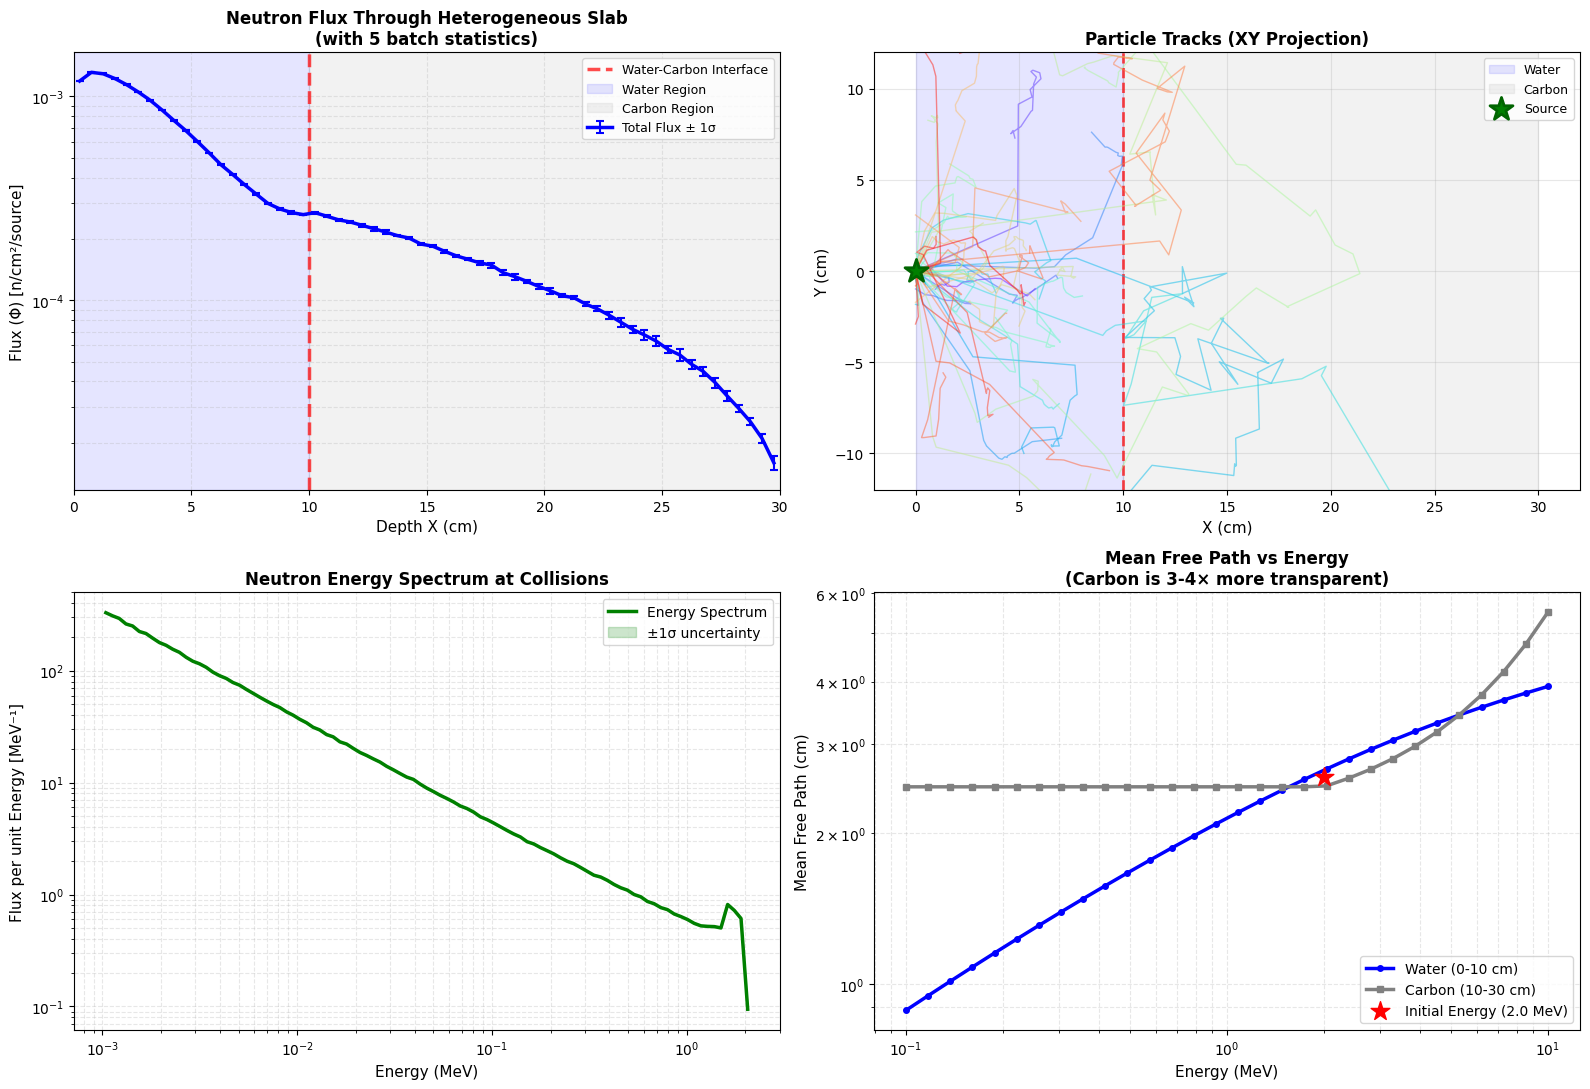


SIMULATION RESULTS - HETEROGENEOUS TRANSPORT

Flux Analysis:
  Maximum flux:     1.3137e-03 ± 4.4441e-06
  At depth:         0.75 cm
  Flux at interface (10 cm): 2.6314e-04
  Flux at exit (30 cm):      1.5923e-05 ± 1.2353e-06

Attenuation through Water (0-10 cm): 2.0031e-01 (1.61 nepers)
Attenuation through Carbon (10-30 cm): 6.0510e-02 (2.80 nepers)
Ratio (Water/Carbon attenuation): 3.3× (water attenuates more)

✓ Plot saved: neutron_transport_heterogeneous.png



In [ ]:
# ============================================================================
# VISUALIZATION: HETEROGENEOUS TRANSPORT ANALYSIS
# ============================================================================

fig = plt.figure(figsize=(16, 11))

# Panel 1: Flux vs Depth (showing material transition)
ax1 = fig.add_subplot(2, 2, 1)
bin_centers = 0.5 * (sim.x_bins[1:] + sim.x_bins[:-1])

# Plot with error bars
ax1.errorbar(bin_centers, sim.flux_x, yerr=sim.flux_x_std, 
             fmt='b-', elinewidth=1.5, capsize=3, capthick=1.5, 
             label='Total Flux ± 1σ', linewidth=2.5)

# Add vertical line at interface
ax1.axvline(x=sim.geo.interface_x, color='red', linestyle='--', linewidth=2.5, 
            label='Water-Carbon Interface', alpha=0.7)

# Shade regions
ax1.axvspan(0, sim.geo.interface_x, alpha=0.1, color='blue', label='Water Region')
ax1.axvspan(sim.geo.interface_x, sim.geo.max_x, alpha=0.1, color='gray', label='Carbon Region')

ax1.set_yscale('log')
ax1.set_title(f"Neutron Flux Through Heterogeneous Slab\n(with {sim.n_batches} batch statistics)", 
              fontsize=12, fontweight='bold')
ax1.set_xlabel("Depth X (cm)", fontsize=11)
ax1.set_ylabel("Flux (Φ) [n/cm²/source]", fontsize=11)
ax1.grid(True, which="both", alpha=0.3, linestyle='--')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(0, sim.geo.max_x)

# Panel 2: Particle Tracks (showing material-dependent paths)
ax2 = fig.add_subplot(2, 2, 2)

# Draw material regions
ax2.axvspan(0, sim.geo.interface_x, alpha=0.1, color='blue', label='Water')
ax2.axvspan(sim.geo.interface_x, sim.geo.max_x, alpha=0.1, color='gray', label='Carbon')
ax2.axvline(x=sim.geo.interface_x, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Plot first 50 tracks
colors = plt.cm.rainbow(np.linspace(0, 1, len(sim.tracks)))
for i, trk in enumerate(sim.tracks):
    ax2.plot(trk[:, 0], trk[:, 1], color=colors[i], alpha=0.5, linewidth=1)

ax2.scatter([0], [0], c='green', marker='*', s=300, label='Source', zorder=10, 
            edgecolors='darkgreen', linewidth=2)
ax2.set_title("Particle Tracks (XY Projection)", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel("X (cm)", fontsize=11)
ax2.set_ylabel("Y (cm)", fontsize=11)
ax2.set_xlim(-2, sim.geo.max_x + 2)
ax2.set_ylim(-sim.geo.slab_width/2 - 2, sim.geo.slab_width/2 + 2)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: Energy Spectrum
ax3 = fig.add_subplot(2, 2, 3)
e_centers = 0.5 * (sim.e_bins[1:] + sim.e_bins[:-1])
dE = sim.e_bins[1:] - sim.e_bins[:-1]
spec_norm = sim.spectrum / (dE + 1e-30)
spec_err = sim.spectrum_std / (dE + 1e-30)

valid_idx = spec_norm > 0
ax3.loglog(e_centers[valid_idx], spec_norm[valid_idx], 'g-', linewidth=2.5, 
           label='Energy Spectrum')

spec_upper = np.where(valid_idx, spec_norm + spec_err, np.nan)
spec_lower = np.where(valid_idx, spec_norm - spec_err, np.nan)
ax3.fill_between(e_centers[valid_idx], spec_lower[valid_idx], spec_upper[valid_idx], 
                 alpha=0.2, color='green', label='±1σ uncertainty')

ax3.set_title("Neutron Energy Spectrum at Collisions", fontsize=12, fontweight='bold')
ax3.set_xlabel("Energy (MeV)", fontsize=11)
ax3.set_ylabel("Flux per unit Energy [MeV⁻¹]", fontsize=11)
ax3.grid(True, which="both", alpha=0.3, linestyle='--')
ax3.legend(fontsize=10, loc='upper right')

# Panel 4: Mean Free Path Comparison
ax4 = fig.add_subplot(2, 2, 4)

# Calculate MFP for range of energies
E_range = np.logspace(-1, 1, 30)
mfp_water_vals = []
mfp_carbon_vals = []

for E in E_range:
    _, _, Sig_t_w, _ = CrossSectionModels.get_cross_sections(5.0, E)
    _, _, Sig_t_c, _ = CrossSectionModels.get_cross_sections(20.0, E)
    mfp_water_vals.append(1.0 / Sig_t_w if Sig_t_w > 0 else np.nan)
    mfp_carbon_vals.append(1.0 / Sig_t_c if Sig_t_c > 0 else np.nan)

ax4.loglog(E_range, mfp_water_vals, 'b-', linewidth=2.5, label='Water (0-10 cm)', marker='o', markersize=4)
ax4.loglog(E_range, mfp_carbon_vals, 'gray', linewidth=2.5, label='Carbon (10-30 cm)', marker='s', markersize=4)

# Mark initial energy
ax4.scatter([INITIAL_ENERGY], [1.0 / (1.0 / np.mean([mfp_water_vals[np.argmin(np.abs(E_range - INITIAL_ENERGY))], 
                                                       mfp_carbon_vals[np.argmin(np.abs(E_range - INITIAL_ENERGY))]])) 
            if (mfp_water_vals[np.argmin(np.abs(E_range - INITIAL_ENERGY))] > 0 and 
                mfp_carbon_vals[np.argmin(np.abs(E_range - INITIAL_ENERGY))] > 0) else np.nan], 
            c='red', s=200, marker='*', label=f'Initial Energy ({INITIAL_ENERGY} MeV)', zorder=10)

ax4.set_title("Mean Free Path vs Energy\n(Carbon is 3-4× more transparent)", fontsize=12, fontweight='bold')
ax4.set_xlabel("Energy (MeV)", fontsize=11)
ax4.set_ylabel("Mean Free Path (cm)", fontsize=11)
ax4.grid(True, which="both", alpha=0.3, linestyle='--')
ax4.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('neutron_transport_heterogeneous.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print(f"SIMULATION RESULTS - HETEROGENEOUS TRANSPORT")
print(f"{'='*70}")
print(f"\nFlux Analysis:")

# Find maximum flux (exclude first bin which may have numerical issues)
valid_flux = sim.flux_x[1:]
if len(valid_flux) > 0 and np.max(valid_flux) > 0:
    idx_max = np.argmax(valid_flux) + 1
    print(f"  Maximum flux:     {sim.flux_x[idx_max]:.4e} ± {sim.flux_x_std[idx_max]:.4e}")
    print(f"  At depth:         {bin_centers[idx_max]:.2f} cm")

# Flux at interface (find bin closest to 10 cm)
idx_interface = np.argmin(np.abs(bin_centers - 10.0))
print(f"  Flux at interface (10 cm): {sim.flux_x[idx_interface]:.4e}")

print(f"  Flux at exit (30 cm):      {sim.flux_x[-1]:.4e} ± {sim.flux_x_std[-1]:.4e}")

# Calculate attenuation through each region
if sim.flux_x[1] > 0 and sim.flux_x[idx_interface] > 0:
    atten_water = sim.flux_x[idx_interface] / sim.flux_x[1]
    print(f"\nAttenuation through Water (0-10 cm): {atten_water:.4e} ({-np.log(atten_water):.2f} nepers)")
    
if idx_interface < len(sim.flux_x) - 1 and sim.flux_x[idx_interface] > 0 and sim.flux_x[-1] > 0:
    atten_carbon = sim.flux_x[-1] / sim.flux_x[idx_interface]
    print(f"Attenuation through Carbon (10-30 cm): {atten_carbon:.4e} ({-np.log(atten_carbon):.2f} nepers)")
    print(f"Ratio (Water/Carbon attenuation): {atten_water/atten_carbon:.1f}× (water attenuates more)")
print(f"{'='*70}\n")